# Project 4

## Reminder: US Accidents (New York Subset) Dataset Overview

[Our dataset](https://docs.google.com/spreadsheets/d/1KY1tcftko3W9Fp-ZbceReVZD2G58tGEhJw6xMqyzIDw/edit?usp=sharing) (generated in ProjEx1) is a processed subset of the nationwide US Accidents (2016–2023) [dataset](https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents), filtered for incidents occurring in NYC ($N=18,883$ after cleaning).

| Var | Type | Data Type | Description |
| --- | --- | --- | --- |
| **`accident_id`** | Categorical | `int64` | Unique numeric identifier extracted from the original ID. |
| **`severity_of_traffic`** | Ordinal | `int8` | Severity score **1–4** (1 = lowest impact, 4 = highest impact). |
| **`traffic_disruption_duration`** | Continuous | `float64` | Duration of the traffic impact in **hours**. |
| **`distance_of_traffic`** | Continuous | `float64` | Distance in **miles** over which traffic flow was affected. |
| **`is_day`** | Binary | `int8` | **1** = Day, **0** = Night (derived from Sunrise/Sunset). |
| **`is_traffic_signal`** | Binary | `int8` | **1** = Yes, **0** = No (presence of a traffic signal nearby). |

The dataset focuses on traffic impact, where both duration and distance exhibit extreme right-skewness. `traffic_disruption_duration` contains massive outliers (up to ~3,967h) despite a low median (1.26h), while `distance_of_traffic` is also zero-inflated.

### Importing the data

In [1]:
import pandas as pd

url = "https://docs.google.com/spreadsheets/d/1mJ3MtFkxHFdTEki1HjrdkAfIvekmWvltFn5S1KRnna8/export?format=csv"
df = pd.read_csv(url)
df.head()

import pandas as pd
url = "https://docs.google.com/spreadsheets/d/1mJ3MtFkxHFdTEki1HjrdkAfIvekmWvltFn5S1KRnna8/export?format=csv"


df = pd.read_csv(url)

file_path = "database.csv"
df.to_csv(file_path, index=False, encoding="utf-8-sig")

df.head()



,accident_id,severity_of_traffic,traffic_disruption_duration,distance_of_traffic,is_day,is_traffic_signal
0,194408,2,0.493611,0.01,1,1
1,194422,3,0.494167,1.13,1,0
2,194475,2,0.491389,0.01,1,0
3,194540,2,0.497500,0.01,0,1
4,194558,2,0.492222,0.01,1,1


# Part 1 : Linear Regression with Bootstrap

### Recap from Previous Task

**Research Question:**  
How do factors such as the presence of a nearby traffic signal, the distance of traffic disruption, and the severity of the traffic impact affect the duration of traffic disruption caused by accidents in New York City?

**Variables Used:**
- **Response Variable:**  
  `traffic_disruption_duration` — a continuous variable representing the duration of traffic disruption (in hours).

- **Explanatory Variables:**  
  - `is_traffic_signal` — binary variable indicating whether a traffic signal is present nearby (`1 = Yes`, `0 = No`).  
  - `distance_of_traffic` — continuous variable indicating the distance over which traffic was affected (in miles).  
  - `severity_of_traffic` — ordinal variable (`1–4`), where higher values indicate more severe traffic impact.


In [2]:
import pandas as pd
import numpy as np

# Set seed globally
np.random.seed(42)

# Load data
df = pd.read_csv("database.csv")

# Select only relevant columns
cols = [
    "traffic_disruption_duration",
    "is_traffic_signal",
    "distance_of_traffic",
    "severity_of_traffic"
]
# Sample 200 observations
df_sample = df.sample(n=200, random_state=42)

# Show first rows
df_sample.head()


,accident_id,severity_of_traffic,traffic_disruption_duration,distance_of_traffic,is_day,is_traffic_signal
409,207796,2,0.500000,0.000,1,0
4828,1988712,2,0.992778,0.000,1,0
42,196154,3,0.736667,0.010,1,0
18595,7690226,2,6.000000,0.155,1,0
6824,2872577,2,0.496667,0.000,1,0


### Question 1: 


**Section (a)**


In [3]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy.stats import norm

# Define X and y
y = df_sample["traffic_disruption_duration"]
X = df_sample[["is_traffic_signal", "distance_of_traffic", "severity_of_traffic"]]
X = sm.add_constant(X)  # add intercept

# Fit linear regression
model = sm.OLS(y, X).fit()

# Get coefficients and standard errors
coefs = model.params
se = model.bse

# Compute 95% confidence intervals using normal approximation
z = norm.ppf(0.975)
ci_lower = coefs - z * se
ci_upper = coefs + z * se

# Combine results into a DataFrame
ci_df = pd.DataFrame({
    "Coefficient": coefs,
    "Std. Error": se,
    "95% CI Lower": ci_lower,
    "95% CI Upper": ci_upper
})

ci_df


,Coefficient,Std. Error,95% CI Lower,95% CI Upper
const,3.476078,1.368666,0.793541,6.158614
is_traffic_signal,0.192277,0.657702,-1.096794,1.481349
distance_of_traffic,1.205270,0.385035,0.450616,1.959925
severity_of_traffic,-0.792699,0.584020,-1.937357,0.351958


**Section (b)**

In [4]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy.stats import norm

# Prepare X and y
y = df_sample["traffic_disruption_duration"].values
X = np.column_stack([
    np.ones(len(df_sample)),  # intercept
    df_sample["is_traffic_signal"].values,
    df_sample["distance_of_traffic"].values,
    df_sample["severity_of_traffic"].values
])
names = ["const", "is_traffic_signal", "distance_of_traffic", "severity_of_traffic"]

# Fit original model
model = sm.OLS(y, X).fit()
beta_hat = model.params

# ----- BOOTSTRAP -----
B = 400
np.random.seed(1)
boot_coefs = np.zeros((B, X.shape[1]))

for b in range(B):
    indices = np.random.choice(len(df_sample), size=len(df_sample), replace=True)
    X_boot = X[indices]
    y_boot = y[indices]
    
    model_b = sm.OLS(y_boot, X_boot).fit()
    boot_coefs[b] = model_b.params

# Compute bootstrap standard errors
se_boot = boot_coefs.std(axis=0)

# Compute normal approximation CI using bootstrap SE
z = norm.ppf(0.975)
ci_lower = beta_hat - z * se_boot
ci_upper = beta_hat + z * se_boot

# Combine into DataFrame
ci_boot_df = pd.DataFrame({
    "Coefficient": beta_hat,
    "Boot SE": se_boot,
    "95% CI Lower (boot)": ci_lower,
    "95% CI Upper (boot)": ci_upper
}, index=names)

ci_boot_df


,Coefficient,Boot SE,95% CI Lower (boot),95% CI Upper (boot)
const,3.476078,1.092687,1.334451,5.617704
is_traffic_signal,0.192277,0.511255,-0.809765,1.194320
distance_of_traffic,1.205270,0.384575,0.451517,1.959024
severity_of_traffic,-0.792699,0.450285,-1.675242,0.089843


**Section (c)**

In [5]:
import numpy as np
import pandas as pd

# Sample size
n = len(df_sample)
alpha = 0.05

# ----- BOOTSTRAP FOR PIVOTAL METHOD -----
B = 400
np.random.seed(1)

G_boot = np.zeros((B, X.shape[1]))

for b in range(B):
    indices = np.random.choice(n, size=n, replace=True)
    X_boot = X[indices]
    y_boot = y[indices]

    beta_b = sm.OLS(y_boot, X_boot).fit().params
    G_boot[b] = np.sqrt(n) * (beta_b - beta_hat)

# Compute pivotal confidence intervals
ci_lower = []
ci_upper = []

for j in range(X.shape[1]):
    g_low = np.percentile(G_boot[:, j], 100 * (alpha / 2))
    g_high = np.percentile(G_boot[:, j], 100 * (1 - alpha / 2))

    ci_lower.append(beta_hat[j] - g_high / np.sqrt(n))
    ci_upper.append(beta_hat[j] - g_low / np.sqrt(n))

# Combine results into DataFrame (same structure)
ci_pivot_df = pd.DataFrame({
    "Coefficient": beta_hat,
    "95% CI Lower (pivotal)": ci_lower,
    "95% CI Upper (pivotal)": ci_upper
}, index=names)

ci_pivot_df


,Coefficient,95% CI Lower (pivotal),95% CI Upper (pivotal)
const,3.476078,1.154221,5.339823
is_traffic_signal,0.192277,-0.753244,1.198717
distance_of_traffic,1.205270,0.319534,1.856595
severity_of_traffic,-0.792699,-1.558187,0.227445


**Section (d)**

In [6]:
import numpy as np
import pandas as pd

alpha = 0.05

# Percentile bootstrap CI
ci_lower = []
ci_upper = []

for j in range(boot_coefs.shape[1]):
    lower = np.percentile(boot_coefs[:, j], 100 * (alpha / 2))
    upper = np.percentile(boot_coefs[:, j], 100 * (1 - alpha / 2))
    
    ci_lower.append(lower)
    ci_upper.append(upper)

# Combine results into DataFrame (same structure style)
ci_percentile_df = pd.DataFrame({
    "Coefficient": beta_hat,
    "95% CI Lower (percentile)": ci_lower,
    "95% CI Upper (percentile)": ci_upper
}, index=names)

ci_percentile_df


,Coefficient,95% CI Lower (percentile),95% CI Upper (percentile)
const,3.476078,1.612332,5.797934
is_traffic_signal,0.192277,-0.814163,1.137799
distance_of_traffic,1.205270,0.553946,2.091007
severity_of_traffic,-0.792699,-1.812843,-0.027212


### Question 2:

In [7]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

# ----- 1. Fit model on full data -----
y_full = df["traffic_disruption_duration"].values.reshape(-1, 1)
X_full = np.column_stack([
    np.ones(len(df)),  # intercept
    df["is_traffic_signal"].values,
    df["distance_of_traffic"].values,
    df["severity_of_traffic"].values
])

model_full = sm.OLS(y_full, X_full).fit()
coefficients_full = model_full.params  # true β from full dataset

# Convert each CI DataFrame to a list of (name, lower, upper) tuples
ci = [(name, ci_df.loc[name, "95% CI Lower"], ci_df.loc[name, "95% CI Upper"]) for name in names]
ci_b = [(name, ci_boot_df.loc[name, "95% CI Lower (boot)"], ci_boot_df.loc[name, "95% CI Upper (boot)"]) for name in names]
cis_pivot = [(name, ci_pivot_df.loc[name, "95% CI Lower (pivotal)"], ci_pivot_df.loc[name, "95% CI Upper (pivotal)"]) for name in names]
cis_percentile = [(name, ci_percentile_df.loc[name, "95% CI Lower (percentile)"], ci_percentile_df.loc[name, "95% CI Upper (percentile)"]) for name in names]


# ----- 2. Utility: extract CI bounds from lists -----
def ci_list_to_arrays(ci_list):
    lows = np.array([low for _, low, high in ci_list])
    highs = np.array([high for _, low, high in ci_list])
    return lows, highs

# Assuming these lists exist:
# ci, ci_b, cis_pivot, cis_percentile
low, high = ci_list_to_arrays(ci)
low_b, high_b = ci_list_to_arrays(ci_b)
low_piv, high_piv = ci_list_to_arrays(cis_pivot)
low_per, high_per = ci_list_to_arrays(cis_percentile)

# Align full-sample β to same order:
beta_full_vec = np.array([coefficients_full[j] for j in range(len(names))])

# ----- 3. Build comparison table -----
rows = []
for j, name in enumerate(names):
    rows.append({
        "coef": name,
        "method": "Normal",
        "length": round(high[j] - low[j], 3),
        "covers_beta_full": (low[j] <= beta_full_vec[j] <= high[j])
    })
    rows.append({
        "coef": name,
        "method": "Normal (boot SE)",
        "length": round(high_b[j] - low_b[j], 3),
        "covers_beta_full": (low_b[j] <= beta_full_vec[j] <= high_b[j])
    })
    rows.append({
        "coef": name,
        "method": "Pivot (root-n)",
        "length": round(high_piv[j] - low_piv[j], 3),
        "covers_beta_full": (low_piv[j] <= beta_full_vec[j] <= high_piv[j])
    })
    rows.append({
        "coef": name,
        "method": "Percentile",
        "length": round(high_per[j] - low_per[j], 3),
        "covers_beta_full": (low_per[j] <= beta_full_vec[j] <= high_per[j])
    })

# ----- 4. Show summary -----
summary = pd.DataFrame(rows)
print(summary)


                   coef            method  length  covers_beta_full
0                 const            Normal   5.365              True
1                 const  Normal (boot SE)   4.283              True
2                 const    Pivot (root-n)   4.186              True
3                 const        Percentile   4.186              True
4     is_traffic_signal            Normal   2.578              True
5     is_traffic_signal  Normal (boot SE)   2.004              True
6     is_traffic_signal    Pivot (root-n)   1.952              True
7     is_traffic_signal        Percentile   1.952              True
8   distance_of_traffic            Normal   1.509              True
9   distance_of_traffic  Normal (boot SE)   1.508              True
10  distance_of_traffic    Pivot (root-n)   1.537              True
11  distance_of_traffic        Percentile   1.537             False
12  severity_of_traffic            Normal   2.289              True
13  severity_of_traffic  Normal (boot SE)   1.76

The classical normal approximation gave the widest intervals, while bootstrap methods were shorter. Pivotal and percentile results were similar. Most methods covered the estimates for const, is_traffic_signal, and distance_of_traffic, but only the classical normal CI covered severity_of_traffic. While bootstrap CIs are tighter, they might struggle with skewed data.

### Question 3:

**Section (a)**

In [8]:
# Get the remaining data (not in the 200-sample)
rest = df.loc[~df.index.isin(df_sample.index)]

# Take 100 holdout points
holdout = rest.sample(n=100, random_state=42)

# Build X_new (design matrix for prediction)
X_new = np.column_stack([
    np.ones(len(holdout)),  # intercept
    holdout["is_traffic_signal"].values,
    holdout["distance_of_traffic"].values,
    holdout["severity_of_traffic"].values
]).astype(float)

# Actual response values
y_new_true = holdout["traffic_disruption_duration"].values

# Predicted values using model trained on 200-sample
y_new_pred = model.predict(X_new)  # or: X_new @ beta_hat

# Optional: combine into one DataFrame
holdout_results = holdout.copy()
holdout_results["y_true"] = y_new_true
holdout_results["y_pred"] = y_new_pred

holdout_results[["y_true", "y_pred"]].head()


,y_true,y_pred
1445,0.724167,1.097979
3943,0.753056,1.097979
4058,1.460000,1.890679
6864,0.746111,2.082956
11276,0.529167,2.833200


**Section (b)**

In [9]:
from scipy.stats import norm
import pandas as pd
import numpy as np
import statsmodels.api as sm

# Set parameters
B = 400
alpha = 0.05
n = len(df_sample)

# Prepare design matrices
X = np.column_stack([
    np.ones(len(df_sample)),  # intercept
    df_sample["is_traffic_signal"].values,
    df_sample["distance_of_traffic"].values,
    df_sample["severity_of_traffic"].values
])
y = df_sample["traffic_disruption_duration"].values

X_new = np.column_stack([
    np.ones(len(holdout)),
    holdout["is_traffic_signal"].values,
    holdout["distance_of_traffic"].values,
    holdout["severity_of_traffic"].values
]).astype(float)
y_new_true = holdout["traffic_disruption_duration"].values
y_new_pred = model.predict(X_new)

# Bootstrap predictions
rng = np.random.default_rng(123)
y_new_boot = np.empty((B, len(holdout)))

b_done = 0
while b_done < B:
    idx = rng.integers(0, n, size=n)  # sample with replacement
    Xb = X[idx, :]
    yb = y[idx]
    beta_b = sm.OLS(yb, Xb).fit().params
    y_new_boot[b_done, :] = X_new @ beta_b
    b_done += 1

# Percentile CIs for each new prediction
ci_lower = np.quantile(y_new_boot, alpha / 2, axis=0)
ci_upper = np.quantile(y_new_boot, 1 - alpha / 2, axis=0)

# Results DataFrame
results = pd.DataFrame({
    "y_true": y_new_true,
    "y_pred": y_new_pred,
    "ci_lower": ci_lower,
    "ci_upper": ci_upper
})

# print all 100 rows in results nicely (truncated to 3 decimal places)
for i in results.index:
    print(f"Index {i}: y_true={results.loc[i, 'y_true']:.3f}, y_pred={results.loc[i, 'y_pred']:.3f}, "
          f"ci_lower={results.loc[i, 'ci_lower']:.3f}, ci_upper={results.loc[i, 'ci_upper']:.3f}")

Index 0: y_true=0.724, y_pred=1.098, ci_lower=0.468, ci_upper=1.739
Index 1: y_true=0.753, y_pred=1.098, ci_lower=0.468, ci_upper=1.739
Index 2: y_true=1.460, y_pred=1.891, ci_lower=1.374, ci_upper=2.492
Index 3: y_true=0.746, y_pred=2.083, ci_lower=1.234, ci_upper=2.977
Index 4: y_true=0.529, y_pred=2.833, ci_lower=2.082, ci_upper=3.900
Index 5: y_true=2.064, y_pred=3.182, ci_lower=2.320, ci_upper=4.541
Index 6: y_true=1.520, y_pred=2.083, ci_lower=1.234, ci_upper=2.977
Index 7: y_true=0.747, y_pred=1.891, ci_lower=1.374, ci_upper=2.492
Index 8: y_true=0.500, y_pred=2.083, ci_lower=1.234, ci_upper=2.977
Index 9: y_true=0.908, y_pred=2.861, ci_lower=2.101, ci_upper=3.951
Index 10: y_true=0.183, y_pred=2.202, ci_lower=1.630, ci_upper=2.870
Index 11: y_true=0.701, y_pred=2.757, ci_lower=2.032, ci_upper=3.765
Index 12: y_true=1.472, y_pred=2.989, ci_lower=2.142, ci_upper=4.098
Index 13: y_true=1.240, y_pred=1.891, ci_lower=1.374, ci_upper=2.492
Index 14: y_true=9.219, y_pred=2.437, ci_low

**Section (c)**

In [10]:
# Check whether true value falls inside CI
results["covered"] = (results["y_true"] >= results["ci_lower"]) & (results["y_true"] <= results["ci_upper"])

# Compute coverage rate
coverage_rate = results["covered"].mean() * 100  # in percent

print(f"Empirical coverage rate: {coverage_rate:.2f}%")


Empirical coverage rate: 31.00%


The value is lower than the expected 95%, this might be because the model fails to capture some important aspects of the data (as shown in projex3), leading to undercoverage.

**Section (d)**

To construct a prediction interval for a new point $Y_{\text{new}}$, rather than just a confidence interval for its expected value $\mathbb{E}[\hat{Y}_{\text{new}}]$, we must account for the regression coefficients ($\hat{\beta}$) and the random error term ($\varepsilon \sim N(0, \sigma^2)$), even if the model were known

For each bootstrap iteration $b = 1, \dots, B$ resample the 200-sample dataset with replacement and fit a linear regression model on the resampled data to get $\hat{\beta}^{(b)}$
Thus:
     $$ \hat{Y}_{\text{new}}^{(b)} = X_{\text{new}} \cdot \hat{\beta}^{(b)} $$
Now, we can sample a residual with replacement from the residuals of the bootstrap model:  
     $$ e^{(b)} \sim \text{sample from residuals} $$
And find: 
     $$ Y_{\text{new}}^{*(b)} = \hat{Y}_{\text{new}}^{(b)} + e^{(b)} $$

After $B$ iterations, collect the values:  
   $$ \{ Y_{\text{new}}^{*(1)}, Y_{\text{new}}^{*(2)}, \dots, Y_{\text{new}}^{*(B)} \} $$

To construct the prediction interval by taking the empirical 2.5th percentile (lower bound) 97.5th percentile (upper bound)
to get an approximate 95% prediction interval for $Y^{\text{new}}$ that reflects both the estimation error and the intrinsic noise in the data.


## Part 2 :  Hypothesis Testing

**Recap from Previous Task**

### Research Question:

Is the average `traffic_disruption_duration` different between accidents that occur with a nearby traffic signal (`is_traffic_signal = 1`) and those without (`is_traffic_signal = 0`)?

Reminder:

- `traffic_disruption_duration` is a continuous variable representing the length of time traffic was disrupted.
- `is_traffic_signal` is a binary categorical variable indicating whether there is a traffic signal near the accident location  
  (`1 = yes`, `0 = no`).


### Question 1

### Research Question Formulation

Is the distribution of `traffic_disruption_duration` values in the `is_traffic_signal = 1` group  
greater than the distribution of `traffic_disruption_duration` values in the `is_traffic_signal = 0` group?


We are interested in testing whether traffic disruption durations tend to be greater when a traffic signal is present.

Let:
- Group 1 = observations where `is_traffic_signal = 1`
- Group 2 = observations where `is_traffic_signal = 0`

Let $\mu_1$ and $\mu_2$ denote the mean traffic disruption durations in group 1 and group 2, respectively.

We test the following hypotheses:

- Null hypothesis ($H_0$): $\mu_1 = \mu_2$
- Alternative hypothesis ($H_1$): $\mu_1 > \mu_2$



### Question 2:

In [11]:
# Randomly select 200 rows (reproducible with random_state)
df_sample = df.sample(n=200, random_state=42).reset_index(drop=True)

# Preview the result
df_sample.head()

,accident_id,severity_of_traffic,traffic_disruption_duration,distance_of_traffic,is_day,is_traffic_signal
0,207796,2,0.500000,0.000,1,0
1,1988712,2,0.992778,0.000,1,0
2,196154,3,0.736667,0.010,1,0
3,7690226,2,6.000000,0.155,1,0
4,2872577,2,0.496667,0.000,1,0


### Question 3:

**Section (a)**

In [12]:
# Group means using correct naming
mu_estimates = df_sample.groupby("is_traffic_signal")["traffic_disruption_duration"].mean()

mu_1 = mu_estimates.loc[1]  # Group with traffic signal
mu_2 = mu_estimates.loc[0]  # Group without traffic signal

delta_hat = mu_1 - mu_2

# Display
print("mu1 (signal = 1):", round(mu_1, 3))
print("mu2 (signal = 0):", round(mu_2, 3))
print("delta_hat = mu1 - mu2:", round(delta_hat, 3))

mu1 (signal = 1): 2.311
mu2 (signal = 0): 2.389
delta_hat = mu1 - mu2: -0.078


This is not an MLE (necessarily) because we have not specified the distribution of the data or the likelihood function.

**Section (b)**

In [13]:
import numpy as np

# Split groups
g1 = df_sample.loc[df_sample["is_traffic_signal"] == 1, "traffic_disruption_duration"].astype(float).values
g2 = df_sample.loc[df_sample["is_traffic_signal"] == 0, "traffic_disruption_duration"].astype(float).values

n1, n2 = len(g1), len(g2)
m1, m2 = g1.mean(), g2.mean()
s1, s2 = g1.std(ddof=1), g2.std(ddof=1)

delta_hat = m1 - m2
SE = np.sqrt(s1**2 / n1 + s2**2 / n2)

# 95% Confidence Interval using normal approximation
z = 1.96  # for alpha = 0.05
ci = (delta_hat - z * SE, delta_hat + z * SE)

print("95% CI for delta:", ci)


95% CI for delta: (-1.20830429275109, 1.052161351548503)


By using the estimator for standard error when the variance is unknown we can use this estimator: $\widehat{\text{se}} = \sqrt{\frac{s_1^2}{n_1} + \frac{s_2^2}{n_2}}$
Assuming that $\hat{\delta}$ is approximately normally distributed due to the Central Limit Theorem
Then the CI will be: $$ \hat{\delta} \pm z_{\alpha/2} \cdot \widehat{\text{se}} $$

**Section (c)**

In [14]:
# Columns needed
cols = ['is_traffic_signal', 'traffic_disruption_duration']
df_all = df[cols].dropna().copy()

# Full groups
g1_all = df_all.loc[df_all["is_traffic_signal"] == 1, "traffic_disruption_duration"].astype(float).values
g2_all = df_all.loc[df_all["is_traffic_signal"] == 0, "traffic_disruption_duration"].astype(float).values

# Estimate delta on full data
delta_full = g1_all.mean() - g2_all.mean()
print("delta (all data):", delta_full)

# Check if within previous CI
ci_lower, ci_upper = ci
print("Is delta in CI:", ci_lower <= delta_full <= ci_upper)


delta (all data): 0.835066952805537
Is delta in CI: True


**Yes, the estimator based on the full data is within the confidence interval calculated from the subsample.**


**Section (d)**

1. Permutation:
$$
\begin{aligned}
H_0: F_{X_1} & =F_{X_2} \\
H_1: F_{X_1} & \succ F_{X_2}
\end{aligned}
$$

$$\text {T.S}: T_0 \equiv \mu_1 - \mu_2$$
$$\text{ R.R.}: \frac{\#\left\{T_j \geq T_0\right\}}{\binom{N}{n}} < \alpha $$


2. Wald:

$$H_0:\delta=0$$
$$H_1:\delta>0$$

$$\begin{aligned}
\text { T.S. }: & W=\frac{\hat{\mu_1}-\hat{\mu_2}}{\sqrt{\frac{s_1^2}{n}+\frac{s_2^2}{m}}} \\
\text { R.R. }: & W>z_{1-{\alpha}}
\end{aligned}$$

In [15]:
import numpy as np
from scipy.stats import norm

# ---------------------------------------------
# Wald Test
# ---------------------------------------------
# Split groups
g0 = df_sample.loc[df_sample["is_traffic_signal"] == 0, "traffic_disruption_duration"].astype(float).values
g1 = df_sample.loc[df_sample["is_traffic_signal"] == 1, "traffic_disruption_duration"].astype(float).values

n0, n1 = len(g0), len(g1)
m0, m1 = g0.mean(), g1.mean()
s0, s1 = g0.std(ddof=1), g1.std(ddof=1)

# Estimate
delta_hat = m1 - m0

# Pooled variance
sp2 = ((n0 - 1)*s0**2 + (n1 - 1)*s1**2) / (n0 + n1 - 2)
SE = np.sqrt(sp2 * (1/n0 + 1/n1))

# Wald statistic and p-value (one-sided)
t_stat = delta_hat / SE
pval_wald = 1 - norm.cdf(t_stat)

print("Wald one-sided test:")
print(f" delta_hat = {delta_hat:.3f}, SE = {SE:.3f}, t = {t_stat:.3f}, p = {pval_wald:.4f}")

# ---------------------------------------------
# Permutation Test (Lecture Notation)
# ---------------------------------------------
rng = np.random.default_rng(42)
B = 10000  # number of permutations (as in lecture)

x = df_sample["traffic_disruption_duration"].astype(float).values
labels = df_sample["is_traffic_signal"].astype(int).values

# Observed statistic
obs = x[labels == 1].mean() - x[labels == 0].mean()

T_star = np.empty(B)
for b in range(B):
    perm = rng.permutation(labels)
    T_star[b] = x[perm == 1].mean() - x[perm == 0].mean()

# One-sided permutation p-value
pval_perm = (np.sum(T_star >= obs) + 1) / (B + 1)

print("Permutation test (one-sided, greater):")
print(f" observed delta = {obs:.3f}, p = {pval_perm:.4f}")


Wald one-sided test:
 delta_hat = -0.078, SE = 0.662, t = -0.118, p = 0.5470
Permutation test (one-sided, greater):
 observed delta = -0.078, p = 0.5059



In both cases we fail to reject the null hypothesis at the 5% level.
This means a statistically significant evidence that accidents with a nearby traffic signal have longer traffic disruption durations could not be detected in the sample.


### Question 4

**Section (a)**

In [16]:
# Question 5a: Estimate medians and delta
g0 = df_sample.loc[df_sample["is_traffic_signal"] == 0, "traffic_disruption_duration"].astype(float).values
g1 = df_sample.loc[df_sample["is_traffic_signal"] == 1, "traffic_disruption_duration"].astype(float).values

m0_hat = np.median(g0)  # no traffic signal
m1_hat = np.median(g1)  # traffic signal

delta_hat = m1_hat - m0_hat

print("Median with signal (m1):", round(m1_hat, 3))
print("Median without signal (m0):", round(m0_hat, 3))
print("delta_hat (m1 - m0):", round(delta_hat, 3))


Median with signal (m1): 0.988
Median without signal (m0): 1.142
delta_hat (m1 - m0): -0.154


We still dont have any model so this is not necessarily an MLE.

**Section (b)**
We use bootstrap to estimate the standard error of the median difference between the two groups.

In [17]:
# Question 5b: Bootstrap percentile CI for delta (difference in medians)
B = 400
rng = np.random.default_rng(123)
deltas = np.empty(B)

for b in range(B):
    g0_b = rng.choice(g0, size=n0, replace=True)
    g1_b = rng.choice(g1, size=n1, replace=True)
    deltas[b] = np.median(g1_b) - np.median(g0_b)

alpha = 0.05
ci_low, ci_high = np.quantile(deltas, [alpha / 2, 1 - alpha / 2])
print(f"95% bootstrap percentile CI for delta: [{ci_low:.3f}, {ci_high:.3f}]")


95% bootstrap percentile CI for delta: [-0.746, 0.771]


**Section (c)**

In [18]:
# Question 5c: Estimate delta (median difference) using full data

g0_all = df.loc[df["is_traffic_signal"] == 0, "traffic_disruption_duration"].astype(float).values
g1_all = df.loc[df["is_traffic_signal"] == 1, "traffic_disruption_duration"].astype(float).values

m0_hat_all = np.median(g0_all)  # no signal
m1_hat_all = np.median(g1_all)  # signal

delta_hat_all = m1_hat_all - m0_hat_all
print("Delta (all data):", round(delta_hat_all, 3))
print("Is delta_hat_all inside the CI?", ci_low <= delta_hat_all <= ci_high)



Delta (all data): -0.016
Is delta_hat_all inside the CI? True


**Section (d)**

In [19]:
# Question 5d: Permutation test for delta (median difference)

rng = np.random.default_rng(42)
B = 10_000  # number of permutations

x = df_sample["traffic_disruption_duration"].astype(float).values
labels = df_sample["is_traffic_signal"].astype(int).values

# Observed statistic: difference in medians
obs_median = np.median(x[labels == 1]) - np.median(x[labels == 0])

# Permutation distribution
T_star = np.empty(B)
for b in range(B):
    perm = rng.permutation(labels)
    T_star[b] = np.median(x[perm == 1]) - np.median(x[perm == 0])

# One-sided p-value (greater)
pval_perm_median = (np.sum(T_star >= obs_median) + 1) / (B + 1)

# Output
print("Permutation test (one-sided, median-based):")
print(f" observed delta = {obs_median:.3f}, p = {pval_perm_median:.4f}")


Permutation test (one-sided, median-based):
 observed delta = -0.154, p = 0.6800


**Conclusion:**  
Since the p-value is much greater than 0.05, we fail to reject the null hypothesis.  
There is no evidence that the median traffic disruption duration is higher when a traffic signal is present.

**Section (e)**

The sample median is not a maximum likelihood estimator under the normal model, and its sampling distribution is not straightforward. While the distribution of the sample median is asymptotically normal, its variance depends on the density at the median, which is unknown and difficult to estimate. As a result, a Wald test for median differences is theoretically possible, but not practical in this context. t-test also requires normality and focuses on means rather than medians. In contrast, non-paramteric tests (e.g.: used in part (d)) is more appropriate for testing median differences.

### Question 5

In [20]:
from scipy.stats import rankdata
import numpy as np

# Data setup
g0 = df_sample.loc[df_sample["is_traffic_signal"] == 0, "traffic_disruption_duration"].astype(float).values
g1 = df_sample.loc[df_sample["is_traffic_signal"] == 1, "traffic_disruption_duration"].astype(float).values

n0, n1 = len(g0), len(g1)
N = n0 + n1

# Combine and rank the data
x_all = np.concatenate([g0, g1])
ranks = rankdata(x_all, method="average")  # average method handles ties correctly

# Rank sum S1: sum of ranks for group 1 (signal = 1)
S1 = ranks[n0:].sum()

# Permutation test (one-sided, greater)
# We prefer this over Normal Approximation because the tie-correction formula is complex
B = 10_000
rng = np.random.default_rng(123)

obs = S1
labels = np.r_[np.zeros(n0, dtype=int), np.ones(n1, dtype=int)]

perm_stats = np.empty(B)
for b in range(B):
    perm = rng.permutation(labels)
    perm_stats[b] = ranks[perm == 1].sum()

p_perm = (np.sum(perm_stats >= obs) + 1) / (B + 1)
print(f"Permutation p-value (one-sided, greater): {p_perm:.4f}")

Permutation p-value (one-sided, greater): 0.4743


While a normal approximation is possible, the presence of ties requires using the complex tie-corrected variance formula. Using the standard uncorrected formula would be inaccurate. Since we are already implementing a computational solution, using the permutation (subsampling) test is preferred as it handles ties naturally and provides an exact result without needing manual formula adjustments.

The results are consistent, indicating that the distribution of traffic disruption duration is not significantly greater in accidents with a nearby traffic signal compared to those without.

We fail to reject $H_0$, and conclude that there is no statistically significant difference in medians between the two groups.

### Question 6

Taken together, the results of Questions 3–5 are consistent.  
Across all approaches: mean-based tests, median-based tests, and rank-based tests, we find **no statistical evidence** that traffic disruption duration is greater when a traffic signal is present.

In Question 3, the difference in group means was small and negative, and both the one-sided Wald test and the permutation test produced large p-values. This indicates no significant difference in mean traffic disruption duration between the two groups.

In Question 4, when focusing on medians, the bootstrap percentile confidence interval for the median difference contained zero, and the estimator based on the full dataset also lay within this interval. The permutation test for the median difference likewise failed to reject the null hypothesis.

In Question 5, the rank-sum test yielded a rank statistic close to its null expectation. Both the permutation-based p-value and the normal approximation were large and nearly identical, again providing no evidence against the null hypothesis.

These conclusions are consistent with the histograms: the distributions of traffic disruption duration for accidents with and without a traffic signal appear highly skewed and largely overlapping, with no clear shift in central tendency. The heavy tails and skewness visible in the histograms further justify the use of nonparametric methods, which nonetheless to the same overall conclusion.

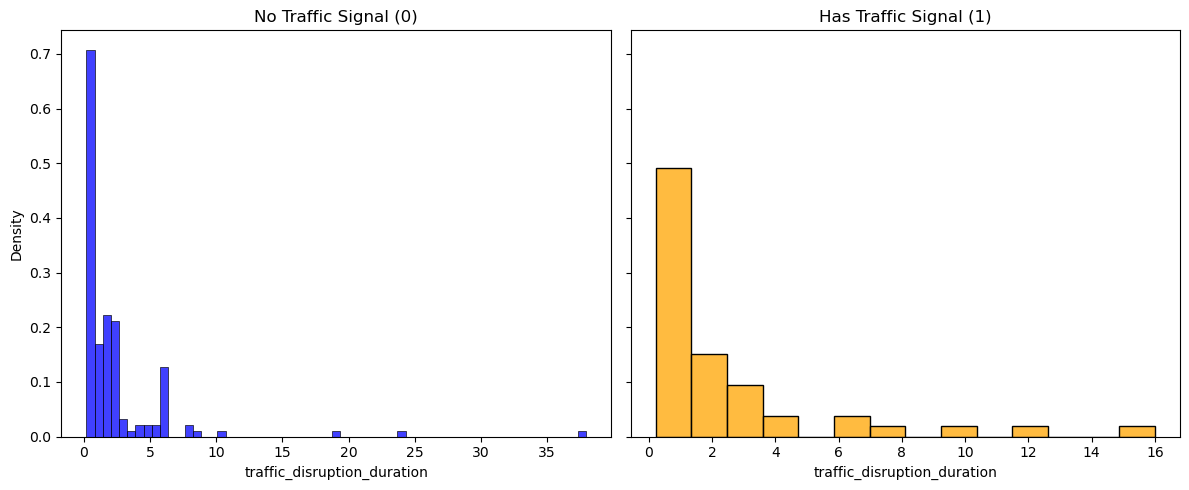

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True) # sharey makes Y-axis scale same for fair comparison

# Plot Group 0 (No Signal)
sns.histplot(
    data=df_sample[df_sample["is_traffic_signal"] == 0], 
    x="traffic_disruption_duration", 
    color="blue",
    stat="density", 
    ax=axes[0]
)
axes[0].set_title("No Traffic Signal (0)")

# Plot Group 1 (Signal)
sns.histplot(
    data=df_sample[df_sample["is_traffic_signal"] == 1], 
    x="traffic_disruption_duration", 
    color="orange",
    stat="density", 
    ax=axes[1]
)
axes[1].set_title("Has Traffic Signal (1)")

plt.tight_layout()
plt.show()